# Tutorial 1 — optimizing an ADI reduction of β Pictoris (VLT/NACO L′)

**klip-tpe** searches the parameter space of a KLIP/ADI reduction (KL modes, temporal
binning, high-pass filter, azimuthal zones, reference exclusion angles, frame selection,
which nights/groups to combine) with a Tree-structured Parzen Estimator, scoring every
trial by the S/N of fake companions injected at fresh random positions, then
*validates* the best candidates on independent injections so the winner is not a lucky
draw.  It is the Python port of the optimizer used for the NEAR/VISIR and LBTI/NOMIC
mid-infrared campaigns, with the same live display and product set.

This notebook runs the whole pipeline on a small public data set — the VIP tutorial
sequence of β Pictoris (NACO L′, 61 frames, 101×101 px, Absil et al. 2013), which contains
the planet β Pic b at ~0.45″.  It takes a few minutes on a laptop.

```
pip install "klip-tpe[plots]"          # or: pip install -e ".[plots]" from a clone
```
Everything below also works from a terminal (`klip-tpe generic ...`) — see the last section.

In [1]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from klip_tpe import Runner, RunConfig, ValidationConfig, CalibrationConfig
from klip_tpe import datasets
from klip_tpe.instruments import generic
from klip_tpe.display import LiveDisplay

RUN_DIR = os.path.abspath("runs/betapic_naco")      # everything the run produces goes here
# Re-running this notebook RESUMES that directory: a finished annulus is reported complete
# in 0.0 min and no new panels are drawn.  Delete runs/betapic_naco to search again.

## 1. The data

`klip_tpe.datasets.fetch` downloads (once, into `~/.klip_tpe/data`) the three files of
the VIP data set: the registered cube, the derotation angles and an unsaturated PSF.

In [2]:
files = datasets.fetch("naco_betapic")
files

{'cube': '/root/.klip_tpe/data/naco_betapic_cube_cen.fits',
 'angles': '/root/.klip_tpe/data/naco_betapic_derot_angles.fits',
 'psf': '/root/.klip_tpe/data/naco_betapic_psf.fits'}

(61, 101, 101) (61,) (39, 39) field rotation 81.4 deg


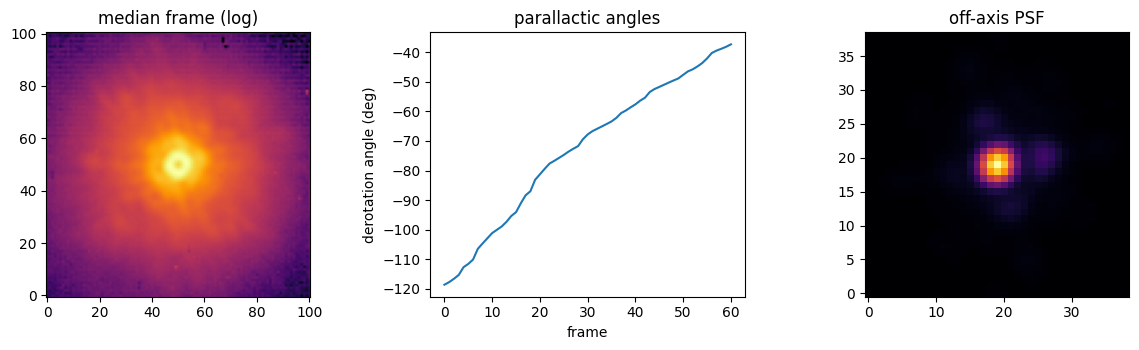

In [3]:
cube = fits.getdata(files["cube"]); angles = fits.getdata(files["angles"]); psf = fits.getdata(files["psf"])
print(cube.shape, angles.shape, psf.shape, f"field rotation {np.ptp(angles):.1f} deg")
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(np.log10(np.clip(np.nanmedian(cube, 0), 1, None)), origin="lower", cmap="inferno"); ax[0].set_title("median frame (log)")
ax[1].plot(angles); ax[1].set_xlabel("frame"); ax[1].set_ylabel("derotation angle (deg)"); ax[1].set_title("parallactic angles")
ax[2].imshow(psf, origin="lower", cmap="inferno"); ax[2].set_title("off-axis PSF")
plt.tight_layout()

## 2. Dataset → reducer → search space

The *generic* adapter takes any registered cube.  Three conventions matter:

* **angles** – klip-tpe derotates each frame counter-clockwise by `angle` (same sign as
  VIP's `angle_list` / pyKLIP's `PAs`); use `angle_sign=-1` for the opposite convention.
* **star flux** – injected companions are expressed as a *contrast* to the star, so the
  adapter needs the star's flux in the science frames' units.  This L′ sequence is
  saturated in the core, so we scale the PSF template to the halo at 6–14 px
  (`star_flux_from_halo`); with an unsaturated core, or a flux frame taken with a known
  neutral density, compute it directly.
* **frame-quality tags** – the searched frame-selection thresholds (`corr_thresh`,
  `noise_max`, `coronoise_max`) act on per-frame tags.  When the data bring none, the
  adapter derives them from the cube itself (`quality_tags`).

`INSTRUMENT` holds the plate scale, wavelength and aperture (λ/D = 3.5 px here).

`make_space` scales the parameter ranges to *these* data: KL modes up to `nframes/5`,
and temporal binning up to `nframes/8` frames per bin so that at least eight bins — and
therefore enough KLIP references — always survive.  (The NEAR production range is 5–30
frames per bin; on a 61-frame cube that would leave two bins and no real subtraction.
`bin_range=(lo, hi)` sets it by hand.)

In [4]:
inst = datasets.INSTRUMENT["naco_betapic"]
ds = generic.load_cube(files["cube"], files["angles"], psf=files["psf"], name="betapic")
star_flux = generic.star_flux_from_halo(ds, r_range_px=(6, 14))
print(f"star flux (template units): {star_flux:.3g};  tags: {list(ds.tags)}")

red = generic.make_reducer({"betapic": ds}, star_flux=star_flux, max_workers="auto", **inst)
space = generic.make_space(red, k_klip_max=30)      # 61 frames -> <=30 KL modes, <=7 frames per temporal bin
space.project = generic.make_guard(red, k_max=30)   # feasibility: enough references per frame etc.
objective, sampler = generic.default_config(red, known=[(0.452, 211.9)])   # keep injections away from beta Pic b
print(space.names)

star flux (template units): 9.11e+05;  tags: ['corrs', 'noises', 'coronoise']
  betapic: 61 frames 101x101 px, PA span 81.4 deg, injection template (flux unit 9.11e+05), fwhm 3.61 px, lambda/D 3.52 px
['bin', 'n_ang', 'filter', 'angsep', 'anglemax', 'corr_thresh', 'noise_max', 'coronoise_max', 'k_klip']


A single reduction with the default parameters (0.3 s) already shows β Pic b at the
expected place (0.452″, PA 211.9°):

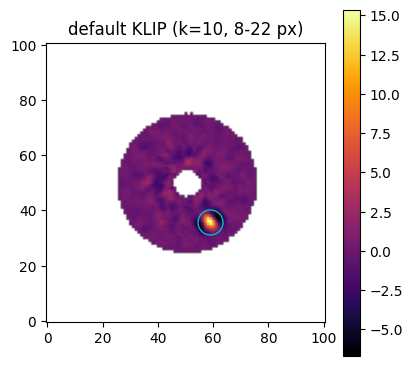

In [5]:
from klip_tpe.reducer import ReductionRequest
cfg0 = space.decode(space.default_vector())
res = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=22, k_klip=10)))
rho_px = 0.452 / inst["pxscale"]; pa = np.deg2rad(211.9)
xb, yb = 50 - rho_px * np.sin(pa), 50 + rho_px * np.cos(pa)
plt.figure(figsize=(4.5, 4.5)); plt.imshow(res.image, origin="lower", cmap="inferno"); plt.plot(xb, yb, "o", mfc="none", mec="c", ms=18)
plt.title("default KLIP (k=10, 8-22 px)"); plt.colorbar();

## 3. Configure the optimization

One annulus, 8–22 px, 60 evaluations of which 15 random warm-up; the two best candidates
are validated on 3 fresh injection sets each.  The injection contrast is *calibrated*
automatically so that the default configuration detects the fakes at S/N ≈ 5 (parameters
matter most where the companion is marginal); `CalibrationConfig(forced=[c])` fixes it.

**The annulus is where the optimization happens.**  Companions are injected at the
area-weighted mid radius of the annulus — √((8² + 22²)/2) = 16.6 px = 0.45″ here, i.e. at
β Pic b's separation, so the parameters are tuned for the region we care about.  A wider
annulus tunes for its own mid radius, which may be nowhere near your target.

Production runs use thousands of evaluations; the protocol is the same.

In [6]:
cfg = RunConfig(ann_edges=[8, 22], n_iter=60, n_init=15, seed=1,
                validation=ValidationConfig(n_top=2, n_valid=3),
                calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                defaults={"k_klip": 10}, fm_curve=True)

## 4. Run with the live display

`LiveDisplay(show="inline")` updates the panel in this output cell after every
evaluation (`show=True` opens it in a matplotlib window instead; `show="auto"` picks).
The same PNGs are written to `steps/`, a progress movie is rebuilt every 10 evaluations
(`annulus01/progress.gif`), and the books (corner, importance, landscapes, products,
verification) are written at the end of the annulus.

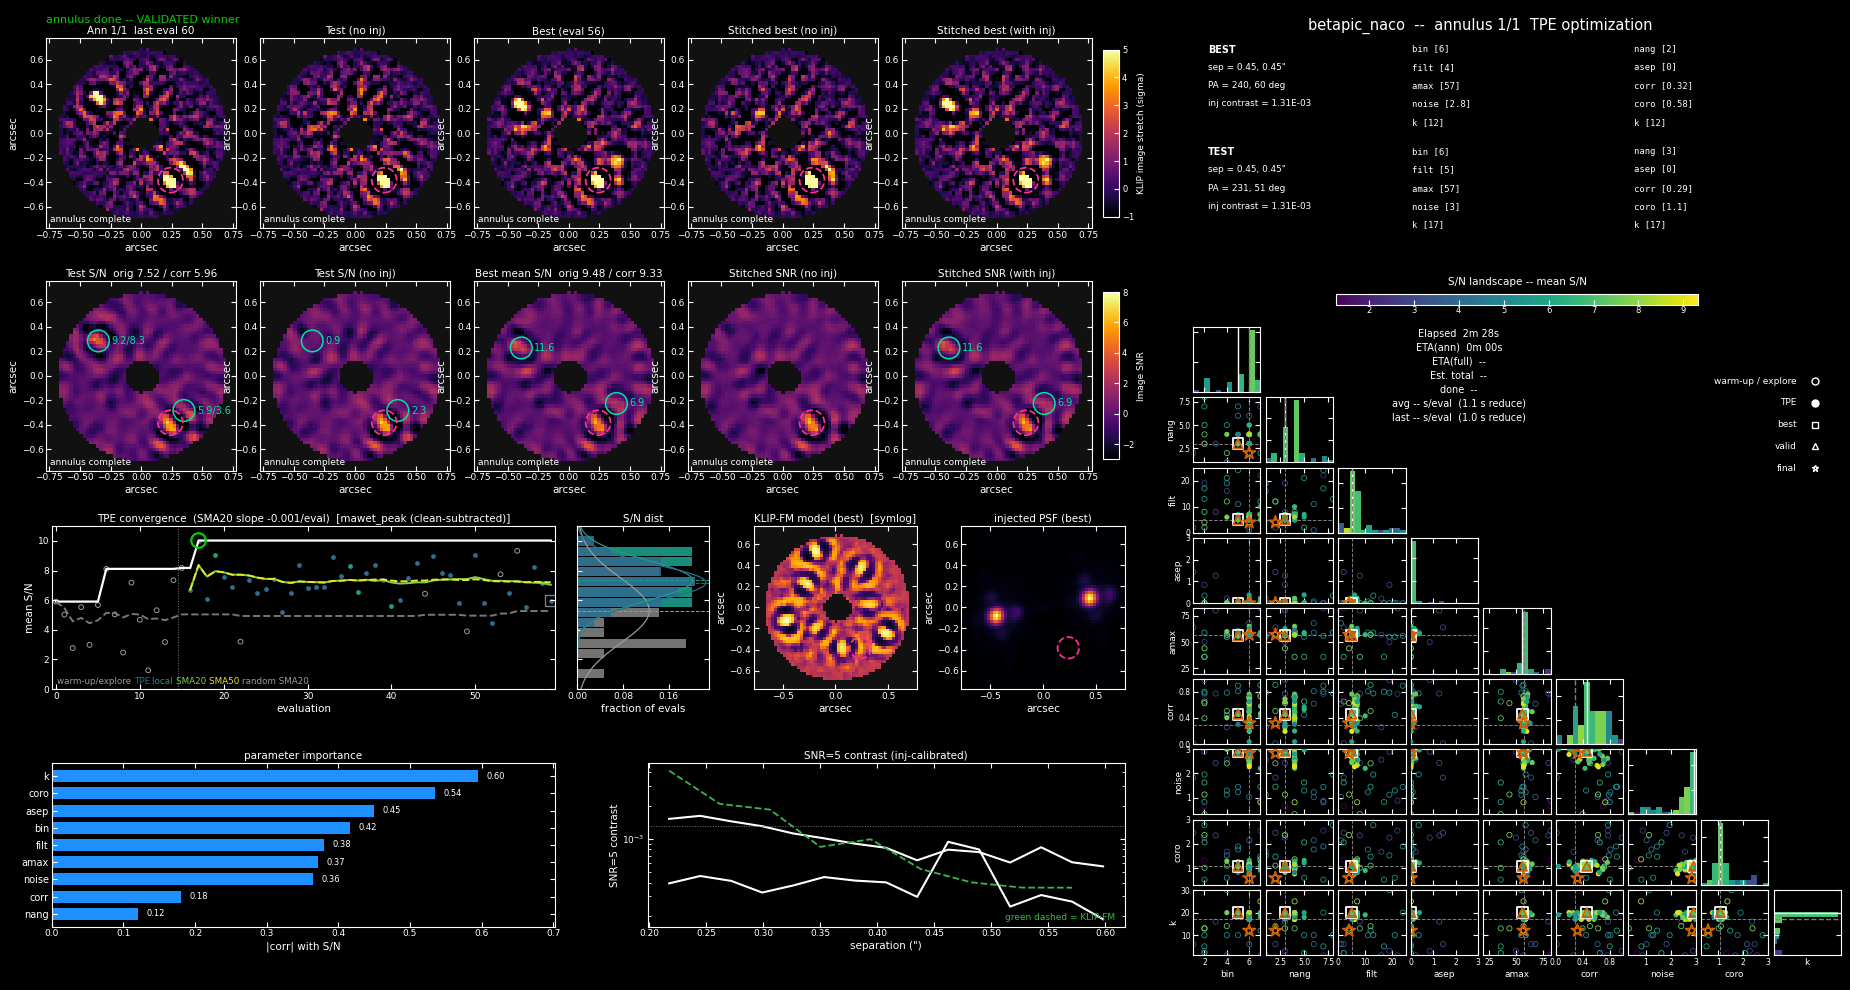

=== annulus 1/1: [8.0, 22.0] px, 2 sources, band 0.450-0.450"


  calibration k-scan: k_default = 12


  calibration trial 1: contrast=3.000e-05  median S/N=-0.11


  calibration trial 2: contrast=3.000e-04  median S/N=1.15


  calibration trial 3: contrast=1.307e-03  median S/N=5.22


...

param_verify config 16/19 (eval 52, score 5.78)
param_verify config 17/19 (eval 53, score 4.49)


param_verify config 18/19 (eval 50, score 3.89)
param_verify config 19/19 (eval 23, score 3.20)


param_verify annulus 01: 19 configs; combine K~2.174E+03


run complete: 1 annuli, 60 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/betapic_naco/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/betapic_naco/opt_steps.mp4']
done in 2.7 min


In [7]:
display = LiveDisplay(RUN_DIR, show="inline", window_scale=0.55, movie_every=10)
runner = Runner(red, space, objective, sampler, cfg, RUN_DIR, callbacks=[display])
t0 = time.time()
results = runner.run()
print(f"done in {(time.time() - t0) / 60:.1f} min")

## 5. Results

`results` holds one `AnnulusResult` per annulus; the same numbers are in
`final_results.json`, `annulus01/winner.json` and the human-readable `results.txt`.

In [8]:
r = results[0]
print(f"search best: eval {r.search_best_index + 1}, S/N {r.search_best_score:.2f}")
print(f"winner:      eval {r.winner_index + 1}, validated {r.validated}, validation median S/N {r.winner_score:.2f}")
print("winner parameters:", {k: v for k, v in r.winner_config['params'].items() if k in space.names})
print("validation table (candidate, trials):")
for row in r.validation_table:
    print(f"   eval {row['eval_index'] + 1}: search S/N {row['search_score']:.2f} -> validation trials "
          f"{np.round(row['trials'], 2)} (median {row['validated_score']:.2f})")

search best: eval 18, S/N 10.03
winner:      eval 56, validated True, validation median S/N 9.25
winner parameters: {'bin': 6, 'n_ang': 2, 'filter': 4, 'angsep': 0.0, 'anglemax': 57, 'corr_thresh': 0.3199538361749259, 'noise_max': 2.8435084920578735, 'coronoise_max': 0.5827641282347515, 'k_klip': 12}
validation table (candidate, trials):
   eval 18: search S/N 10.03 -> validation trials [8.31 8.4  6.6 ] (median 8.31)
   eval 56: search S/N 9.33 -> validation trials [8.69 9.45 9.25] (median 9.25)


The winner's reduction with and without the injected companions, and the final clean
image (β Pic b, no injections).  The real planet is an independent check: it was never
injected, and its S/N is measured with the same matched-filter statistic:

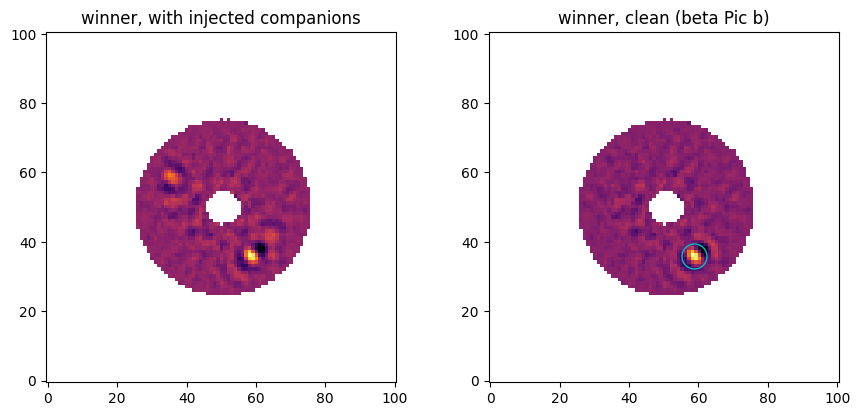

In [9]:
best_inj = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_inj.fits"))
best_clean = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean.fits"))
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
for a, im, t in zip(ax, (best_inj, best_clean), ("winner, with injected companions", "winner, clean (beta Pic b)")):
    a.imshow(im, origin="lower", cmap="inferno"); a.set_title(t)
ax[1].plot(xb, yb, "o", mfc="none", mec="c", ms=18); plt.tight_layout()

In [10]:
from klip_tpe.metrics import MawetPeakSNR
metric = MawetPeakSNR(pxscale=red.pxscale, fwhm=red.fwhm, kernel_fn=red.matched_filter_kernel)
snr_default = metric.per_source(res.image, None, [0.452], [211.9])[0]
snr_winner = metric.per_source(best_clean, None, [0.452], [211.9])[0]
print(f"beta Pic b: S/N {snr_default:.1f} (default)  ->  {snr_winner:.1f} (validated winner)")
print(f"injected companions: S/N ~5 (calibrated default)  ->  {r.winner_score:.1f} (validated winner)")

beta Pic b: S/N 16.1 (default)  ->  18.6 (validated winner)
injected companions: S/N ~5 (calibrated default)  ->  9.2 (validated winner)


The gain on the *injections* (≈5 → 9) is larger than on the planet (16 → 19): the
injections sit near the detection limit, where the parameters matter most, while β Pic b
is far above it.  To tune for a bright known companion, force the injection contrast to
its own with `CalibrationConfig(forced=[c])`.

Contrast curve (5σ, injection-calibrated throughput) of the validated winner, plus the
KLIP forward-model cross-check.  Known companions passed as `known=` are excluded from
the noise rings, so β Pic b does not inflate its own detection limit:

Text(0.5, 1.0, "beta Pic, NACO L'")

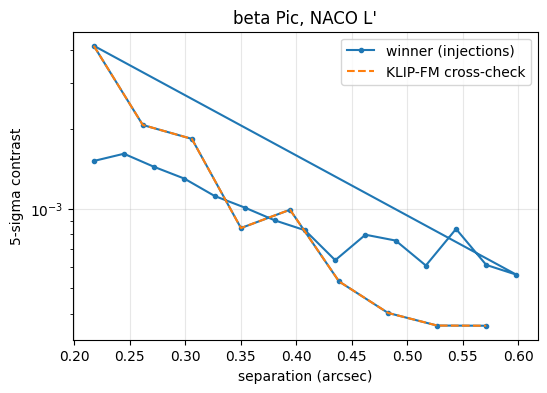

In [11]:
cc = np.loadtxt(os.path.join(RUN_DIR, "annulus01", "contrast_curve.txt"))
plt.figure(figsize=(6, 4)); plt.semilogy(cc[:, 0], cc[:, 1], "-o", ms=3, label="winner (injections)")
if r.fm_curve:
    plt.semilogy(r.fm_curve["r_as"], r.fm_curve["curve"], "--", label="KLIP-FM cross-check")
plt.xlabel("separation (arcsec)"); plt.ylabel("5-sigma contrast"); plt.legend(); plt.grid(alpha=.3); plt.title("beta Pic, NACO L'")

Everything else lives in the run directory — the step frames and movie, and the books:

| file | content |
|---|---|
| `steps/stepNNNN.png`, `annulus01/progress.gif`, `opt_steps.gif` | the live panel per evaluation and the movie |
| `annulus01/corner.pdf`, `landscapes.pdf` | the sampled parameter space, coloured by S/N |
| `annulus01/importance.pdf`, `paracoord.pdf`, `rank.pdf`, `slice.pdf` | which parameters matter |
| `annulus01/products.pdf`, `verify_limits.pdf`, `verify_subsets_inj.pdf` | winner images, S/N maps, detection limits |
| `annulus01/validation_panel.png`, `calibration_panel.png` | the validation and calibration stages |
| `klip_stitched*.fits`, `contrast_curve.txt`, `results.txt` | final images and tables |

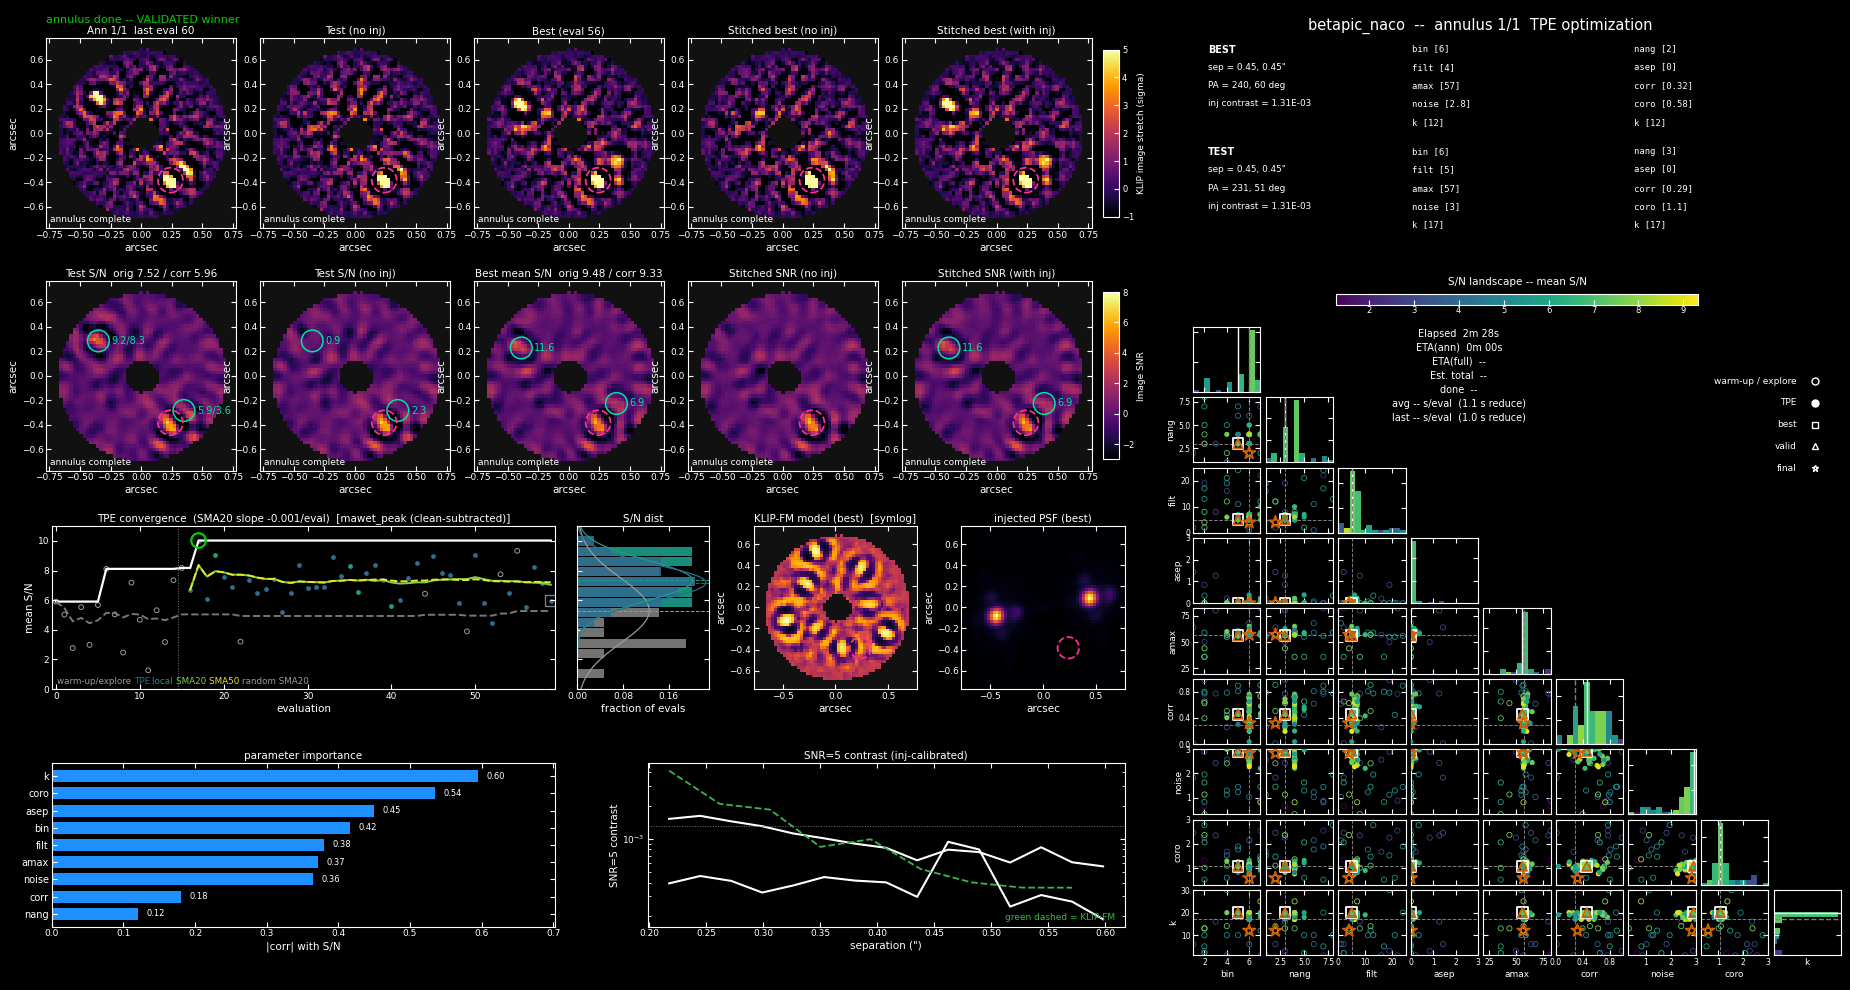

In [12]:
from IPython.display import Image
last_frame = sorted(f for f in os.listdir(os.path.join(RUN_DIR, "steps")) if f.startswith("step"))[-1]
Image(filename=os.path.join(RUN_DIR, "steps", last_frame), width=1000)     # the annulus-end frame

In [13]:
sorted(os.listdir(os.path.join(RUN_DIR, "annulus01")))[:40]

['best_clean.fits',
 'best_clean_partitions.fits',
 'best_fm.fits',
 'best_inj.fits',
 'best_inj_partitions.fits',
 'calib0001_setup.txt',
 'calib0002_setup.txt',
 'calib0003_setup.txt',
 'calibration.json',
 'calibration_panel.png',
 'contrast_curve.txt',
 'corner.pdf',
 'edf.png',
 'eval0001_setup.txt',
 'eval0002_setup.txt',
 'eval0003_setup.txt',
 'eval0004_setup.txt',
 'eval0005_setup.txt',
 'eval0006_setup.txt',
 'eval0007_setup.txt',
 'eval0008_setup.txt',
 'eval0009_setup.txt',
 'eval0010_setup.txt',
 'eval0011_setup.txt',
 'eval0012_setup.txt',
 'eval0013_setup.txt',
 'eval0014_setup.txt',
 'eval0015_setup.txt',
 'eval0016_setup.txt',
 'eval0017_setup.txt',
 'eval0018_setup.txt',
 'eval0019_setup.txt',
 'eval0020_setup.txt',
 'eval0021_setup.txt',
 'eval0022_setup.txt',
 'eval0023_setup.txt',
 'eval0024_setup.txt',
 'eval0025_setup.txt',
 'eval0026_setup.txt',
 'eval0027_setup.txt']

## 6. Other PSF-subtraction engines: VIP and pyKLIP

The optimizer does not care who subtracts the PSF.  `backend="vip"` (VIP's
`pca_annular`) or `backend="pyklip"` (`klip_parallelized`) replace the KLIP core and keep
the injection, frame selection, filtering, binning and scoring — so the same search space
can be compared across engines on the same data.  A single reduction each:

In [14]:
for backend in ("klip", "vip", "pyklip"):
    try:
        red_b = generic.make_reducer({"betapic": ds}, star_flux=star_flux, backend=backend, log=lambda s: None, **inst)
    except Exception as exc:                      # engine not installed
        print(f"{backend}: {exc}"); continue
    t = time.time()
    img = red_b.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=30, k_klip=10))).image
    print(f"{backend:7s} {time.time() - t:5.1f} s   peak {np.nanmax(img):.1f} at {np.unravel_index(np.nanargmax(np.nan_to_num(img, nan=-1e9)), img.shape)[::-1]}")

klip      0.1 s   peak 14.5 at (np.int64(58), np.int64(36))


vip       1.5 s   peak 42.3 at (np.int64(59), np.int64(36))


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 50.51it/s]

pyklip    0.2 s   peak 38.4 at (np.int64(58), np.int64(36))


To optimize with another engine, build the reducer with `backend=` and run exactly the
same cells (`Runner(...)`), e.g. `RUN_DIR + "_vip"`.  Note that KLIP-FM (the forward-model
cross-check curve) exists only for the built-in engine.

## 7. The same from a terminal

```
klip-tpe generic --cube naco_betapic_cube_cen.fits --angles naco_betapic_derot_angles.fits \
    --psf naco_betapic_psf.fits --star-flux halo --pxscale 0.02719 --lam 3.8e-6 --diam 8.2 \
    --known 0.452 211.9 --ann-edges 8 30 --n-iter 60 --n-init 15 --n-top 2 --n-valid 3 \
    --run-dir runs/betapic_cli --show           # --show inline inside Jupyter, --backend vip|pyklip
klip-tpe resume --run-dir runs/betapic_cli      # after an interruption
klip-tpe plots  --run-dir runs/betapic_cli      # regenerate the figures
```

## 8. Your own data

Anything registered on the star works: `generic.load_cube(cube, angles, psf=...,
ref_cube=...)` accepts arrays or FITS paths (a 4-d IFS cube with `wv_index=`), several
`Dataset`s (nights, epochs, IRDIS channels, pyNOMIC image groups …) become *partitions*
that the optimizer tunes and selects individually, and `ref_cube` switches on RDI/ARDI.
For pyNOMIC reductions use the dedicated adapter (`klip-tpe near --instrument nomic`);
for JWST see tutorial 3.